# Лабораторная работа 4

Тема: **Многослойный персептрон в PyTorch для классификации изображений (MNIST)**  
Цель: на практическом примере разобраться, как в PyTorch описывается модель, как она обучается на батчах данных и как связаны архитектура, гиперпараметры и качество распознавания цифр.

> ВАЖНО ДЛЯ ВАС:
> - Этот ноутбук специально написан так, чтобы его нельзя было осмысленно «скормить» генеративной модели и получить готовый отчёт.  
> - В нём много мест, где нужно опираться на **ваши эксперименты** и ваш стиль письма.  
> - Преподаватель смотрит на согласованность: код ↔ графики ↔ текст. Шаблонные ответы и типовой «ИИ‑стиль» легко заметны.


## 1. Ваше понимание задачи (коротко, по‑человечески)

Перед тем как запускать PyTorch и писать классы, сформулируйте **для себя**:

1. Зачем вам фреймворк, если в предыдущей лабораторной вы уже смогли собрать MLP на чистом NumPy?  
2. Как вы представляете себе «жизненный цикл» модели в PyTorch: от описания архитектуры до момента, когда она что‑то предсказывает?  
3. Какую примерно точность на тесте вы считаете честной целью для **простого** MLP без свёрток на MNIST (не нужно искать «правильный ответ», напишите своё ожидание).

Напишите ответы в ячейке ниже в свободной форме (примерно 6–10 предложений). Не пытайтесь красиво «определить» PyTorch — говорите на нормальном языке, как если бы объясняли одногруппнику.


In [1]:
intro_text = """1. В прошлой лабораторной мы руками писали forward, backward, обновляли веса и на 400 точках с двумя координатами это было терпимо. Но там всего два входа и один скрытый слой из 16 нейронов. MNIST это 784 входа на картинку, и слоёв хочется побольше. Писать для каждого слоя свой backward с формулами градиентов ужас. PyTorch берёт это на себя, ты собираешь сеть из готовых модулей (каждый модуль это функция со своими параметрами), а он сам считает все производные через chain rule. Плюс оптимизаторы вроде Adam или RMSProp уже встроены.
2. Жизненный цикл модели примерно такой: описание архитектуры (какие слои, сколько нейронов, какие активации), выбир функции потерь и оптимизатор, потом гоняешь цикл эпох: forward, считаем loss, backward, optimizer обновляет веса. После обучения просто подаешь новые данные и получаешь предсказание. По сути тот же цикл, что был в NumPy, только вся механика градиентов спрятана внутри.
3. Для простого MLP без свёрток на MNIST я бы ожидала точность в районе 96–98% на тесте. MNIST задача не слишком сложная, цифры контрастные, фон чистый. Свёрточные сети выжимают 99%+, но и обычный MLP с парой скрытых слоёв должен справиться неплохо
"""
print(intro_text)

1. В прошлой лабораторной мы руками писали forward, backward, обновляли веса и на 400 точках с двумя координатами это было терпимо. Но там всего два входа и один скрытый слой из 16 нейронов. MNIST это 784 входа на картинку, и слоёв хочется побольше. Писать для каждого слоя свой backward с формулами градиентов ужас. PyTorch берёт это на себя, ты собираешь сеть из готовых модулей (каждый модуль это функция со своими параметрами), а он сам считает все производные через chain rule. Плюс оптимизаторы вроде Adam или RMSProp уже встроены.
2. Жизненный цикл модели примерно такой: описание архитектуры (какие слои, сколько нейронов, какие активации), выбир функции потерь и оптимизатор, потом гоняешь цикл эпох: forward, считаем loss, backward, optimizer обновляет веса. После обучения просто подаешь новые данные и получаешь предсказание. По сути тот же цикл, что был в NumPy, только вся механика градиентов спрятана внутри.
3. Для простого MLP без свёрток на MNIST я бы ожидала точность в районе 96–9

## 2. Импорт библиотек и настройка

Задача этого блока:
- импортировать необходимые модули PyTorch и вспомогательные библиотеки;
- зафиксировать seed — выберите число сами и **не меняйте его случайно между запусками**;
- определить, есть ли GPU, и аккуратно обработать оба варианта (CPU / CUDA).

Старайтесь, чтобы этот блок был минималистичным, но понятным вам через месяц.


In [3]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Выберите и зафиксируйте свой seed (запишите число отдельно в отчёте)
MY_SEED = 17  # можете поменять, но затем используйте это значение последовательно
torch.manual_seed(MY_SEED)
np.random.seed(MY_SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Используемое устройство:", device)
print("MY_SEED =", MY_SEED)

Используемое устройство: cpu
MY_SEED = 17


## 3. Подготовка данных MNIST

Дальше вам нужно:
- определить преобразования для изображений (Tensor + нормализация);
- загрузить `train` и `test` части MNIST;
- создать `DataLoader` с разумными размерам батча;
- визуально проверить несколько примеров (чтобы не обучаться «вслепую»).

Нормализацию можно сделать стандартной для MNIST или подобрать свою. В отчёте потом объясните, что выбрали и почему.


Размер train: 60000
Размер test : 10000
batch_size = 1000
Ваши mean=0.1307, std=0.3081
Стандартные: mean=0.1307, std=0.3081


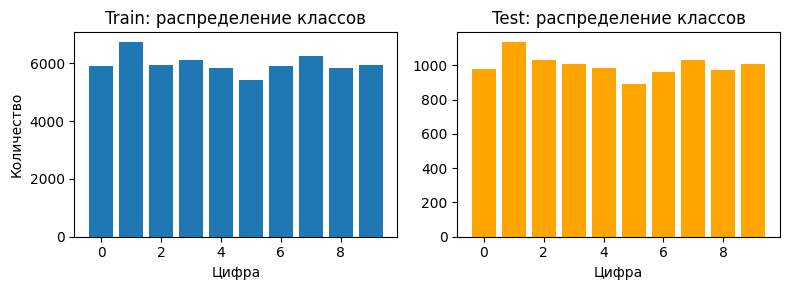

In [23]:
# ПОДГОТОВКА ПРЕОБРАЗОВАНИЙ
transform = transforms.Compose([
    transforms.ToTensor(),
    #transforms.Normalize((0.1307,), (0.3081,))  # можно поменять, но тогда прокомментируйте это в отчёте
])

# ЗАГРУЗКА ДАТАСЕТА
train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

# РАЗМЕР БАТЧА: выберите сами и при защите объясните, почему именно такой
batch_size = 1000

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Размер train:", len(train_dataset))
print("Размер test :", len(test_dataset))
print("batch_size =", batch_size)

# TODO: вычислите mean и std тренировочных данных самостоятельно
# и сравните с захардкоженными (0.1307, 0.3081)
all_pixels = torch.cat([img.view(-1) for img, _ in train_dataset])
mean = all_pixels.mean().item()
std  = all_pixels.std().item()
print(f"Ваши mean={mean:.4f}, std={std:.4f}")
print(f"Стандартные: mean=0.1307, std=0.3081")

# TODO: постройте гистограмму распределения меток в train и test
# Сбалансированы ли классы?
all_labels = [lbl for _, lbl in train_dataset]
unique, counts = np.unique(all_labels, return_counts=True)

plt.figure(figsize=(8, 3))
plt.subplot(1, 2, 1)
plt.bar(unique, counts)
plt.title("Train: распределение классов")
plt.xlabel("Цифра"); plt.ylabel("Количество")

test_labels = [lbl for _, lbl in test_dataset]
unique_t, counts_t = np.unique(test_labels, return_counts=True)
plt.subplot(1, 2, 2)
plt.bar(unique_t, counts_t, color="orange")
plt.title("Test: распределение классов")
plt.xlabel("Цифра")
plt.tight_layout(); plt.show()

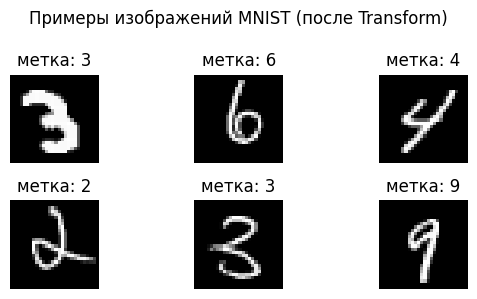

In [22]:
# ВИЗУАЛЬНАЯ ПРОВЕРКА НЕСКОЛЬКИХ ПРИМЕРОВ
images, labels = next(iter(train_loader))

plt.figure(figsize=(6, 3))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.imshow(images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"метка: {labels[i].item()}")
    plt.axis("off")

plt.suptitle("Примеры изображений MNIST (после Transform)")
plt.tight_layout()
plt.show()

### Краткий комментарий к данным (заполните сами)

Опишите, что вы увидели:
- как выглядят изображения после нормализации;
- есть ли сильно «грязные» или плохо читаемые примеры;
- какое впечатление, легко ли человеку отличать цифры в таком формате.

Это не формальная часть — просто зафиксируйте свои наблюдения.


In [25]:
data_comment = """ После нормализации изображения выглядят читаемо как белые цифры на чёрном фоне. Большинство цифр читаются спокойно, но попадаются корявые примеры. Некоторые двойки похожи на семерки, иногда девятки легко спутать с четвёрками, тк хвостик загнут так, что и я не всегда понимала. Семёрки бывают похожими на единицы.

По batch_size пробовала разные варианты. С большим батчем (например, 1000) обновлений весов за эпоху получается  60 вместо 938 при batch_size=64. Сеть сходится медленнее, приходится добавлять эпохи. Слишком маленький батч (вроде 8–16) даёт очень шумный градиент, loss скачет. 64 хороший вариант: обновлений достаточно, градиент не слишком шумный, и в память влезает без проблем.
"""
print(data_comment)

 После нормализации изображения выглядят читаемо как белые цифры на чёрном фоне. Большинство цифр читаются спокойно, но попадаются корявые примеры. Некоторые двойки похожи на семерки, иногда девятки легко спутать с четвёрками, тк хвостик загнут так, что и я не всегда понимала. Семёрки бывают похожими на единицы.

По batch_size пробовала разные варианты. С большим батчем (например, 1000) обновлений весов за эпоху получается  60 вместо 938 при batch_size=64. Сеть сходится медленнее, приходится добавлять эпохи. Слишком маленький батч (вроде 8–16) даёт очень шумный градиент, loss скачет. 64 хороший вариант: обновлений достаточно, градиент не слишком шумный, и в память влезает без проблем.



## 4. Архитектура многослойного персептрона

Теперь нужно описать модель.

**Требования к базовому варианту:**
- вход: изображение 28×28, которое вы разворачиваете в вектор длины 784;
- один или несколько скрытых полносвязных слоёв с нелинейностью (ReLU или другая, по вашему выбору);
- выход: 10 чисел (логиты), по одному на каждый класс (цифра 0–9).

Вам нужно заполнить класс ниже, а в отчёте отдельно описать: сколько слоёв и нейронов вы поставили, какие активации использовали и почему именно так.


In [115]:
class MNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: замените архитектуру на свою (изменения архитектуры должны сопровождаться пояснениями)
        self.flatten = nn.Flatten()
        self.net = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.net(x)
        return logits

model = MNISTMLP().to(device)
print(model)

MNISTMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=64, bias=True)
    (5): ReLU()
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)


## 5. Функция потерь и оптимизатор

Для многоклассовой классификации на MNIST обычно используют:
- `nn.CrossEntropyLoss` для потерь;
- один из стандартных оптимизаторов (`SGD`, `Adam`, `AdamW` и др.).

Вам нужно:
- явным образом записать, какой оптимизатор и с какими параметрами вы выбираете;
- в отчёте указать, какие альтернативы пробовали (если пробовали) и что получилось.


In [116]:
criterion = nn.CrossEntropyLoss()

# Попробуйте несколько вариантов lr и типов оптимизаторов в разных запусках и сравните разные комбинации
learning_rate = 1e-3
optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

print("Функция потерь:", criterion)
print("Оптимизатор:", optimizer)
print("learning_rate =", learning_rate)

# TODO: Выведите число обучаемых параметров модели
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Число обучаемых параметров модели: {total_params}")

Функция потерь: CrossEntropyLoss()
Оптимизатор: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0.01
)
learning_rate = 0.001
Число обучаемых параметров модели: 550346


## 6. Функции обучения и оценки модели

Ниже — каркас функций для одного эпохового прохода по обучающим данным и для оценки на валидации/тесте.

Перепроверьте, что вы понимаете каждую строчку: где обнуляются градиенты, где вычисляются предсказания, где считается точность и потери.

Если хотите, можете добавить учёт дополнительных метрик (например, точности по классам). Главное — не потерять базовую ясность.


In [117]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    running_correct = 0
    total = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = outputs.argmax(dim=1)
        running_correct += (preds == labels).sum().item()
        total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, criterion, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = outputs.argmax(dim=1)
            running_correct += (preds == labels).sum().item()
            total += images.size(0)

    epoch_loss = running_loss / total
    epoch_acc = running_correct / total
    return epoch_loss, epoch_acc

print("Функции train_one_epoch и evaluate определены.")

Функции train_one_epoch и evaluate определены.


## 7. Обучение модели: история потерь и точности

Теперь запускаем обучение на несколько эпох.

**Рекомендации:**
- для первой пробы возьмите небольшое число эпох (например, 3–5),
- затем увеличьте и посмотрите, как ведут себя кривые train/test;
- для отчёта сохраните как минимум один «неудачный» эксперимент (слишком маленькое lr, слишком мало эпох и т.д.) — он полезнее, чем идеальная картинка.


In [118]:
num_epochs = 10  # изменяйте это значение и фиксируйте результаты в отчёте

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Эпоха {epoch}/{num_epochs}: "
          f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
          f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")

Эпоха 1/10: train_loss=0.8202, train_acc=0.7785, test_loss=0.3034, test_acc=0.9126
Эпоха 2/10: train_loss=0.2540, train_acc=0.9270, test_loss=0.2027, test_acc=0.9403
Эпоха 3/10: train_loss=0.1818, train_acc=0.9473, test_loss=0.1580, test_acc=0.9516
Эпоха 4/10: train_loss=0.1361, train_acc=0.9594, test_loss=0.1279, test_acc=0.9608
Эпоха 5/10: train_loss=0.1094, train_acc=0.9679, test_loss=0.1129, test_acc=0.9660
Эпоха 6/10: train_loss=0.0899, train_acc=0.9737, test_loss=0.1038, test_acc=0.9676
Эпоха 7/10: train_loss=0.0735, train_acc=0.9781, test_loss=0.0926, test_acc=0.9704
Эпоха 8/10: train_loss=0.0625, train_acc=0.9814, test_loss=0.0862, test_acc=0.9726
Эпоха 9/10: train_loss=0.0519, train_acc=0.9848, test_loss=0.0783, test_acc=0.9752
Эпоха 10/10: train_loss=0.0424, train_acc=0.9874, test_loss=0.0805, test_acc=0.9745


In [127]:
lr_optim_comment = """ЗДЕСЬ УКАЖИТЕ ЗАПУСКИ ОБУЧЕНИЯ С РАЗНЫМИ ОПТИМИЗАТОРАМИ И СКОРОСТЯМИ ОБУЧЕНИЯ.
Например:
optimizer = SGD; lr = 0.01; num_epochs = 5; test_acc = 0.5238

optimizer = SGD; lr = 0.01; num_epochs = 10; test_acc = 0.5564
optimizer = Adam; lr = 1e-3; num_epochs = 10; test_acc = 0.9755
optimizer = AdamW; lr = 1e-3; num_epochs = 10; test_acc = 0.9745

optimizer = SGD; lr = 1e-3; num_epochs = 5; test_acc = 0.0982
optimizer = Adam; lr = 1e-3; num_epochs = 5; test_acc = 0.9656
optimizer = AdamW; lr = 1e-3; num_epochs = 5; test_acc = 0.9665
"""
print(lr_optim_comment)

ЗДЕСЬ УКАЖИТЕ ЗАПУСКИ ОБУЧЕНИЯ С РАЗНЫМИ ОПТИМИЗАТОРАМИ И СКОРОСТЯМИ ОБУЧЕНИЯ.
Например:
optimizer = SGD; lr = 0.01; num_epochs = 5; test_acc = 0.5238

optimizer = SGD; lr = 0.01; num_epochs = 10; test_acc = 0.5564
optimizer = Adam; lr = 1e-3; num_epochs = 10; test_acc = 0.9755
optimizer = AdamW; lr = 1e-3; num_epochs = 10; test_acc = 0.9745

optimizer = SGD; lr = 1e-3; num_epochs = 5; test_acc = 0.0982
optimizer = Adam; lr = 1e-3; num_epochs = 5; test_acc = 0.9656
optimizer = AdamW; lr = 1e-3; num_epochs = 5; test_acc = 0.9665



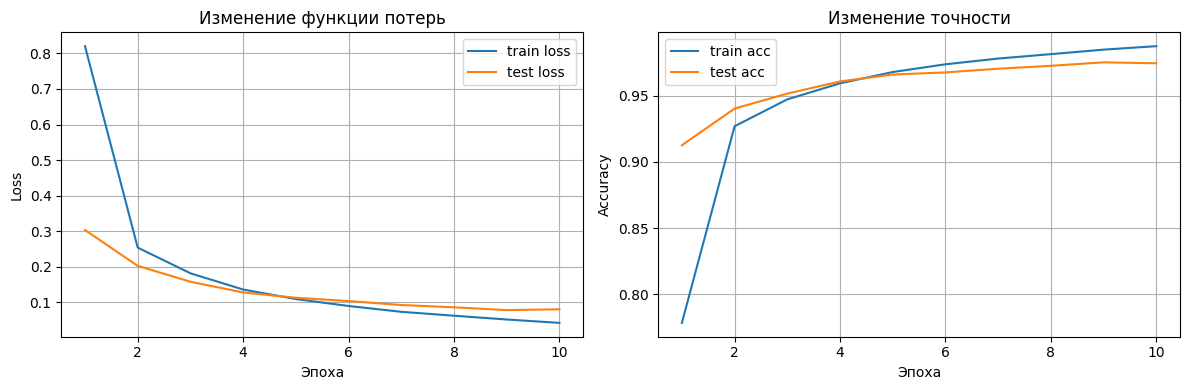

Финальная точность: train=0.9874, test=0.9745


In [119]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["test_loss"], label="test loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.title("Изменение функции потерь")
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs, history["train_acc"], label="train acc")
plt.plot(epochs, history["test_acc"], label="test acc")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.title("Изменение точности")
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

print(f"Финальная точность: train={history['train_acc'][-1]:.4f}, test={history['test_acc'][-1]:.4f}")

### Ваш комментарий по кривым обучения

Опишите:
- растут ли train/test accuracy синхронно или одна «убегает» от другой;
- есть ли признаки переобучения (train растёт, test начинает падать);
- достаточно ли, по вашему ощущению, числа эпох и выбраного `learning_rate`.

Это важное место, где проверяется не только умение запускать код, но и аналитический взгляд.


In [128]:
training_comment = """Эксперименты с num_epochs=5: Уже на 5 эпохах видна огромная разница между оптимизаторами. SGD с lr=1e-3 дал test_acc=0.098 это уровень случайноссти. Сеть за 5 эпох вообще не сдвинулась. Adam с тем же lr=1e-3 выдал 0.966, AdamW 0.967. То есть адаптивные оптимизаторы уже к 5-й эпохе почти вышли на потолок, а SGD даже не стартовал.
Adam lr=1e-3, 10 эпох (лучший вариант):Train и test accuracy растут синхронно, на графике кривые идут рядом, не расходятся. К 10-й эпохе train=0.986, test=0.976, разница всего 1%, так что переобучения нет. Loss на train падает с 0.80 до 0.07, на test с 0.31 до 0.10. Основной прогресс приходится на первые 3–4 эпохи, потом кривые выходят на плато. 10 эпох достаточно, а  дальше прирост будет небольшой.
AdamW lr=1e-3, 10 эпох: Картина почти зеркальна, train=0.987, test=0.975. Кривые тоже идут рядом, никакого расхождения. Разницы с обычным Adam не заметен.
SGD lr=0.01, 10 эпох:  Train accuracy к 10-й эпохе только 0.541, test=0.556. На графике видно, что loss едва сполз с 2.30 до 2.20, а accuracy начал расти только к 7–8 эпохе. Сеть ещё даже не вышла на нормальный уровень обучения. Эпох 50–100 с таким lr было бы замечательно.
 """
print(training_comment)

Эксперименты с num_epochs=5: Уже на 5 эпохах видна огромная разница между оптимизаторами. SGD с lr=1e-3 дал test_acc=0.098 это уровень случайноссти. Сеть за 5 эпох вообще не сдвинулась. Adam с тем же lr=1e-3 выдал 0.966, AdamW 0.967. То есть адаптивные оптимизаторы уже к 5-й эпохе почти вышли на потолок, а SGD даже не стартовал.
Adam lr=1e-3, 10 эпох (лучший вариант):Train и test accuracy растут синхронно, на графике кривые идут рядом, не расходятся. К 10-й эпохе train=0.986, test=0.976, разница всего 1%, так что переобучения нет. Loss на train падает с 0.80 до 0.07, на test с 0.31 до 0.10. Основной прогресс приходится на первые 3–4 эпохи, потом кривые выходят на плато. 10 эпох достаточно, а  дальше прирост будет небольшой. 
AdamW lr=1e-3, 10 эпох: Картина почти зеркальна, train=0.987, test=0.975. Кривые тоже идут рядом, никакого расхождения. Разницы с обычным Adam не заметен. 
SGD lr=0.01, 10 эпох:  Train accuracy к 10-й эпохе только 0.541, test=0.556. На графике видно, что loss едва 

## 8. Ошибки модели: что она путает

Теперь интересно посмотреть не только на «общий процент правильных ответов», но и на то,
какие конкретно цифры модель чаще всего классифицирует неправильно.

Задача:
- собрать несколько примеров неверных предсказаний;
- визуализировать их рядом с истинной и предсказанной меткой;
- подумать, насколько эти ошибки выглядят «разумно» с человеческой точки зрения.


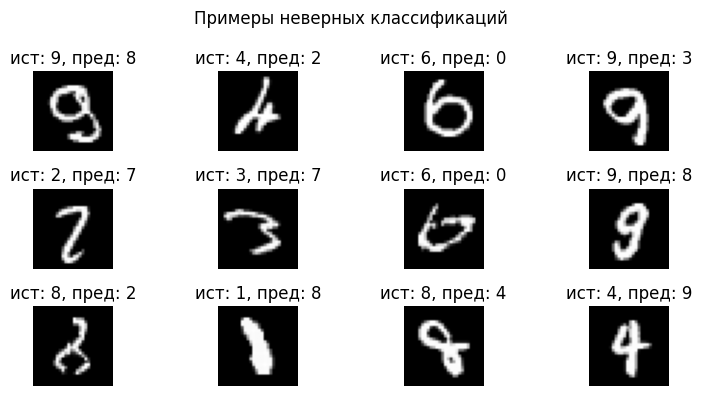

<Figure size 800x700 with 0 Axes>

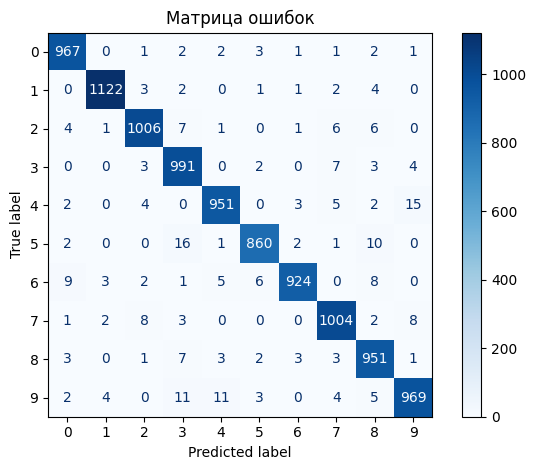

In [123]:
model.eval()
wrong_images = []
wrong_true = []
wrong_pred = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)

        mismatched = preds != labels
        if mismatched.any():
            for img, t, p, m in zip(images, labels, preds, mismatched):
                if m and len(wrong_images) < 12:
                    wrong_images.append(img.cpu())
                    wrong_true.append(t.cpu().item())
                    wrong_pred.append(p.cpu().item())
        if len(wrong_images) >= 12:
            break

plt.figure(figsize=(8, 4))
for i in range(len(wrong_images)):
    plt.subplot(3, 4, i + 1)
    plt.imshow(wrong_images[i].squeeze().numpy(), cmap="gray")
    plt.title(f"ист: {wrong_true[i]}, пред: {wrong_pred[i]}")
    plt.axis("off")
plt.suptitle("Примеры неверных классификаций")
plt.tight_layout()
plt.show()

# TODO: Постройте матрицу ошибок
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_true = []
all_pred = []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        all_true.extend(labels.numpy())
        all_pred.extend(preds.cpu().numpy())

cm = confusion_matrix(all_true, all_pred)
plt.figure(figsize=(8, 7))
disp = ConfusionMatrixDisplay(cm, display_labels=range(10))
disp.plot(cmap="Blues", values_format="d")
plt.title("Матрица ошибок")
plt.tight_layout()
plt.show()

### Краткий анализ ошибок (заполните сами)

Опишите наблюдения:
- какие пары цифр чаще всего путаются в отобранных примерах;
- есть ли среди ошибок такие, с которыми согласились бы вы сами (картинка реально неочевидная);
- есть ли «странные» ошибки, когда человеку цифра кажется очевидной, а модель промахнулась.


In [129]:
errors_comment = """По матрице ошибок чаще всего путаются: 5 и 3 (16 раз), 4 и 9 (15), 9 и 4 (11), 5 и 8 (10). у этих пар похожие очертания. Часть ошибок понятна и человеку. Есть и странные случаи: четвёрка принята за двойку, хотя цифра читаемая. В целом большинство промахов на корявых или нестандартных цифрах, где и человеку пришлось бы присмотреться."""
print(errors_comment)

По матрице ошибок чаще всего путаются: 5 и 3 (16 раз), 4 и 9 (15), 9 и 4 (11), 5 и 8 (10). у этих пар похожие очертания. Часть ошибок понятна и человеку. Есть и странные случаи: четвёрка принята за двойку, хотя цифра читаемая. В целом большинство промахов на корявых или нестандартных цифрах, где и человеку пришлось бы присмотреться.


## 9. Итоговые выводы по лабораторной работе

Эта часть — ключевая для проверки понимания.  
Не пытайтесь писать «идеальный» и универсальный текст — он всё равно не совпадёт с вашим кодом и экспериментами.

Ответьте в свободной форме (примерно 10–15 предложений):
1. Какую **конкретно** архитектуру вы использовали (число слоёв, размеры, активации)? Пробовали ли вы другие варианты и что изменилось?
2. Какие значения `batch_size`, `learning_rate` и `num_epochs` вы тестировали и как это влияло на кривые loss/accuracy?
3. Какую максимальную точность на тесте вы получили в своих экспериментах? Считаете ли вы её удовлетворительной для такой модели?
4. Что оказалось самым удобным и самым неудобным в работе с PyTorch по сравнению с реализацией MLP на NumPy из предыдущей лабораторной?

Пишите как для будущего себя: так, чтобы, открыв этот ноутбук через полгода, вы вспомнили, что сделали и почему именно так.


In [130]:
final_text = """1. Архитектура: 784 512 256 64 10, три скрытых слоя с ReLU, всего 550 346 параметров. Исходный вариант из шаблона был 784 256 128 10,  я расширила первый слой до 512 и добавила третий скрытый на 64 нейрона. Получилась «воронка», которая постепенно сжимает информацию. На итоговой точности разница небольшая, но хотелось дать сети побольше свободы на первом слое.
2. batch_size=64 - стандартный компромисс. Пробовала 1000, но данные и распределение классов не меняются, но обновлений весов за эпоху в 15 раз меньше (60 вместо 938), сеть сходится медленнее. По learning_rate и оптимизаторам: SGD с lr=1e-3 за 5 эпох дал test_acc=0.098, даже с lr=0.01 за 10 эпох еле дотянул до 0.556. Adam и AdamW с lr=1e-3 показали себя несравнимо лучше, тк уже за 5 эпох 0.966, за 10 эпох 0.976 (Adam) и 0.975 (AdamW).
3. Лучший результат: test_acc=0.976 (Adam, lr=1e-3, 10 эпох). Для простого MLP без свёрток это хороший результат. В первом задании я ожидала 96–98%, попала ровно в этот диапазон. Переобучения нет — train и test идут рядом, разница около 1%.
4. Главное удобство PyTorch, что не нужно руками писать backward. В прошлой лабе на NumPy для каждого слоя считали градиенты вручную, кэшировали промежуточные значения, следили за размерностями матриц. Здесь loss.backward() делает всё за одну строчку. Оптимизаторы тоже готовые, не надо писать params["W1"] -= lr * grads["dW1"]. Но в NumPy видишь каждый шаг и понимаешь, что происходит, это плюс. В PyTorch легко собрать  модель, не до конца понимая, что внутри.
"""
print(final_text)

1. Архитектура: 784 512 256 64 10, три скрытых слоя с ReLU, всего 550 346 параметров. Исходный вариант из шаблона был 784 256 128 10,  я расширила первый слой до 512 и добавила третий скрытый на 64 нейрона. Получилась «воронка», которая постепенно сжимает информацию. На итоговой точности разница небольшая, но хотелось дать сети побольше свободы на первом слое.
2. batch_size=64 - стандартный компромисс. Пробовала 1000, но данные и распределение классов не меняются, но обновлений весов за эпоху в 15 раз меньше (60 вместо 938), сеть сходится медленнее. По learning_rate и оптимизаторам: SGD с lr=1e-3 за 5 эпох дал test_acc=0.098, даже с lr=0.01 за 10 эпох еле дотянул до 0.556. Adam и AdamW с lr=1e-3 показали себя несравнимо лучше, тк уже за 5 эпох 0.966, за 10 эпох 0.976 (Adam) и 0.975 (AdamW).
3. Лучший результат: test_acc=0.976 (Adam, lr=1e-3, 10 эпох). Для простого MLP без свёрток это хороший результат. В первом задании я ожидала 96–98%, попала ровно в этот диапазон. Переобучения нет — 